In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3

In [2]:
from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})


In [3]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 256]
box_length = [20000., 20000., 20000.]

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 9, 3, 23, 0, tzinfo=timezone.utc)

# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for September 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ccfile     = f'{atmo3_data}era5/2023/cc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ciwcfile   = f'{atmo3_data}era5/2023/ciwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
clwcfile   = f'{atmo3_data}era5/2023/clwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
rhfile     = f'{atmo3_data}era5/2023/r.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)


2.526086956521739 0.07649950269801416


In [3]:
# 1. Extract the altitude array (in meters)
altitude_profile = atmo_box.super_grid.z
# 2. Extract the calibrated specific humidity profile (in kg/kg) not calibrated
raw_specific_humidity = atmo_box.super_grid.era5_interp2site(spechfile)
# 3. extratc the temperature profile (in K)
temperature_profile = atmo_box.super_grid.era5_interp2site(tempfile)

p_interp = atmo_box.super_grid.pressure

In [4]:
from atmo3 import atm_utils as au
# 1. Calculate Virtual Temperature (K)
# Specific humidity affects air density, so we need the virtual temperature first.
t_v_interp = au.virtual_temperature(T=temperature_profile, q=raw_specific_humidity)

# 2. Calculate Water Vapor Density (kg / m^3)
rho_wv_interp = au.water_vapor_density(q=raw_specific_humidity, P=p_interp, T_v=t_v_interp)

# 3. Integrate over the altitude to get PWV
# We use JAX's trapezoidal integration along the altitude axis (z)
pwv_kg_m2 = jnp.trapezoid(rho_wv_interp, x=altitude_profile)

# 4. Convert units
# 1 kg/m^2 of water is exactly equal to 1 mm of precipitable water!
pwv_mm = pwv_kg_m2

print(f"Calculated ERA5 PWV: {pwv_mm:.3f} mm")

Calculated ERA5 PWV: 1.971 mm


In [4]:
from scipy import constants
import xarray as xr
import pandas as pd
dataset_q = xr.open_dataset(spechfile)

# 1. Calculate the regional standard deviation (all 81 points) for ALL times and levels
std_q_regional_full = dataset_q['q'].std(dim=['latitude', 'longitude'], ddof=1)

# 2. Extract your specific time
# We use .replace(tzinfo=None) to make it timezone-naive so it perfectly matches xarray's datetime64
std_q_sep03 = std_q_regional_full.sel(time=time_utc.replace(tzinfo=None)).values

# Print the shape and the first 5 values to verify it matches your 37 pressure levels
print("Shape of std array:", std_q_sep03.shape)
print("Standard Deviations for Sep 3:", std_q_sep03[:5], "...")

Shape of std array: (37,)
Standard Deviations for Sep 3: [3.9915831e-09 4.2719046e-09 1.2965603e-08 6.8515845e-08 5.4245717e-08] ...


In [5]:
import jax.numpy as jnp

# 1. Reverse your standard deviation array so it goes bottom-up 
# (to match the reversed zgeo_atsite array in SuperGrid)
std_q_reversed = std_q_sep03[::-1]

# 2. Interpolate using the same logic found inside atmo3.super_grid
std_q_interp = jnp.interp(
    atmo_box.super_grid.z,             # Target x: Simulation altitude grid
    atmo_box.super_grid.zgeo_atsite,   # Source x: ERA5 geopotential heights at the site
    std_q_reversed,                    # Source y: Your reversed standard deviation array
    left='extrapolate', 
    right='extrapolate'
)

# std_q_interp is now on the same altitude grid as your raw_specific_humidity

In [6]:
dataset_rh = xr.open_dataset(rhfile)

# 1. Calculate the regional standard deviation (all 81 points) for ALL times and levels
std_rh_regional_full = dataset_rh['r'].std(dim=['latitude', 'longitude'], ddof=1)

# 2. Extract your specific time
# We use .replace(tzinfo=None) to make it timezone-naive so it perfectly matches xarray's datetime64
std_rh_sep03 = std_rh_regional_full.sel(time=time_utc.replace(tzinfo=None)).values

std_rh_reversed = std_rh_sep03[::-1]

# 2. Interpolate using the same logic found inside atmo3.super_grid
std_rh_interp = jnp.interp(
    atmo_box.super_grid.z,             # Target x: Simulation altitude grid
    atmo_box.super_grid.zgeo_atsite,   # Source x: ERA5 geopotential heights at the site
    std_rh_reversed,                    # Source y: Your reversed standard deviation array
    left='extrapolate', 
    right='extrapolate'
)

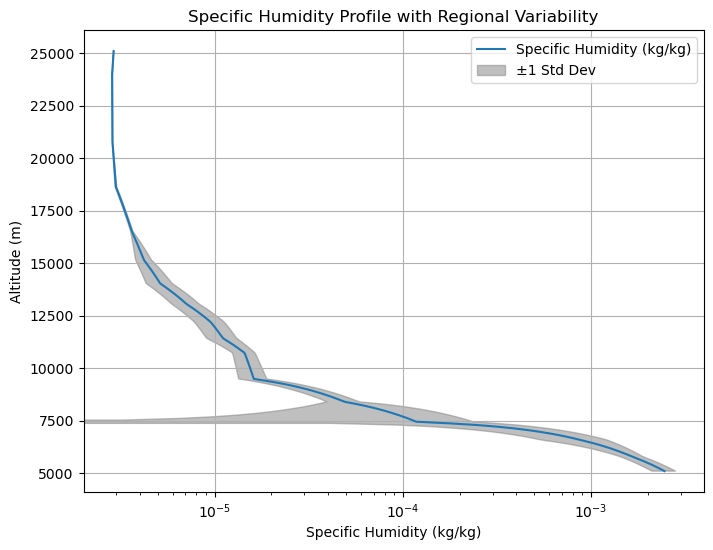

In [8]:
#Let's plot the specific humidity profile and its standard deviation to visualize the variability across the altitude profile
plt.figure(figsize=(8, 6))
plt.plot(raw_specific_humidity, altitude_profile, label='Specific Humidity (kg/kg)')
plt.fill_betweenx(altitude_profile, raw_specific_humidity - std_q_interp, raw_specific_humidity + std_q_interp, color='gray', alpha=0.5, label='±1 Std Dev')
plt.xlabel('Specific Humidity (kg/kg)')
plt.ylabel('Altitude (m)')
plt.title('Specific Humidity Profile with Regional Variability')
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

In [9]:
ds_cc = xr.open_dataset(ccfile)

# 2. Convert coordinates to match the dataset ([-180, 180] -> [0, 360])
target_lon = -67.78 % 360  # This becomes 292.22
target_lat = -22.95

# 3. Select the nearest native grid point to your site
# We use nearest neighbor instead of interpolation to avoid creating "fake" fractional clouds
site_cc = ds_cc['cc'].sel(longitude=target_lon, latitude=target_lat, method='nearest')

# 4. Collapse the vertical column
# We take the maximum cloud cover across all pressure levels for each time step.
# If max_cc is > 0, it means there is a cloud layer somewhere above the site.
max_cc_column = site_cc.max(dim='level')

# 5. Filter for times where cloud cover is strictly greater than zero 
# (We use 0.01 as a threshold to ignore microscopic floating-point noise)
cloudy_data = max_cc_column.where(max_cc_column > 0.01, drop=True)

# 6. Extract the timestamps and convert to a clean Pandas list for viewing
cloudy_times = pd.to_datetime(cloudy_data.time.values)

print(f"Total cloudy hours found in September: {len(cloudy_times)}\n")

# Print the list of dates/times
print("First 30 cloudy times:")
for t in cloudy_times[:30]:
    print(t.strftime('%Y-%m-%d %H:%00 UTC'))

Total cloudy hours found in September: 59

First 30 cloudy times:
2023-09-03 20:%00 UTC
2023-09-03 21:%00 UTC
2023-09-03 22:%00 UTC
2023-09-03 23:%00 UTC
2023-09-04 00:%00 UTC
2023-09-04 01:%00 UTC
2023-09-04 02:%00 UTC
2023-09-04 03:%00 UTC
2023-09-04 04:%00 UTC
2023-09-04 05:%00 UTC
2023-09-04 06:%00 UTC
2023-09-04 07:%00 UTC
2023-09-08 00:%00 UTC
2023-09-12 20:%00 UTC
2023-09-22 17:%00 UTC
2023-09-22 18:%00 UTC
2023-09-22 19:%00 UTC
2023-09-23 04:%00 UTC
2023-09-23 05:%00 UTC
2023-09-23 06:%00 UTC
2023-09-23 07:%00 UTC
2023-09-23 08:%00 UTC
2023-09-23 09:%00 UTC
2023-09-23 10:%00 UTC
2023-09-23 11:%00 UTC
2023-09-23 12:%00 UTC
2023-09-23 13:%00 UTC
2023-09-23 14:%00 UTC
2023-09-23 15:%00 UTC
2023-09-23 16:%00 UTC


In [4]:
ccfile_10     = f'{atmo3_data}era5/2023/cc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

In [6]:
from scipy import constants
import xarray as xr
import pandas as pd
ds_cc = xr.open_dataset(ccfile_10)

# 2. Convert coordinates to match the dataset ([-180, 180] -> [0, 360])
target_lon = -67.78 % 360  # This becomes 292.22
target_lat = -22.95

# 3. Select the nearest native grid point to your site
# We use nearest neighbor instead of interpolation to avoid creating "fake" fractional clouds
site_cc = ds_cc['cc'].sel(longitude=target_lon, latitude=target_lat, method='nearest')

# 4. Collapse the vertical column
# We take the maximum cloud cover across all pressure levels for each time step.
# If max_cc is > 0, it means there is a cloud layer somewhere above the site.
max_cc_column = site_cc.max(dim='level')

# 5. Filter for times where cloud cover is strictly greater than zero 
# (We use 0.01 as a threshold to ignore microscopic floating-point noise)
cloudy_data = max_cc_column.where(max_cc_column > 0.01, drop=True)

# 6. Extract the timestamps and convert to a clean Pandas list for viewing
cloudy_times = pd.to_datetime(cloudy_data.time.values)

print(f"Total cloudy hours found in October: {len(cloudy_times)}\n")

# Print the list of dates/times
print("First 30 cloudy times:")
for t in cloudy_times[:30]:
    print(t.strftime('%Y-%m-%d %H:%00 UTC'))

Total cloudy hours found in October: 212

First 30 cloudy times:
2023-10-03 16:%00 UTC
2023-10-03 17:%00 UTC
2023-10-03 18:%00 UTC
2023-10-04 15:%00 UTC
2023-10-04 16:%00 UTC
2023-10-04 17:%00 UTC
2023-10-04 18:%00 UTC
2023-10-04 19:%00 UTC
2023-10-06 10:%00 UTC
2023-10-06 11:%00 UTC
2023-10-06 12:%00 UTC
2023-10-06 20:%00 UTC
2023-10-06 21:%00 UTC
2023-10-06 22:%00 UTC
2023-10-06 23:%00 UTC
2023-10-07 00:%00 UTC
2023-10-11 06:%00 UTC
2023-10-11 07:%00 UTC
2023-10-11 08:%00 UTC
2023-10-11 09:%00 UTC
2023-10-11 10:%00 UTC
2023-10-11 11:%00 UTC
2023-10-11 12:%00 UTC
2023-10-11 13:%00 UTC
2023-10-11 14:%00 UTC
2023-10-11 15:%00 UTC
2023-10-11 16:%00 UTC
2023-10-11 17:%00 UTC
2023-10-11 18:%00 UTC
2023-10-11 19:%00 UTC


In [10]:
cc_interp = atmo_box.super_grid.era5_interp2site(ccfile)

ciwc_interp = atmo_box.super_grid.era5_interp2site(ciwcfile)
clwc_interp = atmo_box.super_grid.era5_interp2site(clwcfile)

rh_interp = atmo_box.super_grid.era5_interp2site(rhfile)

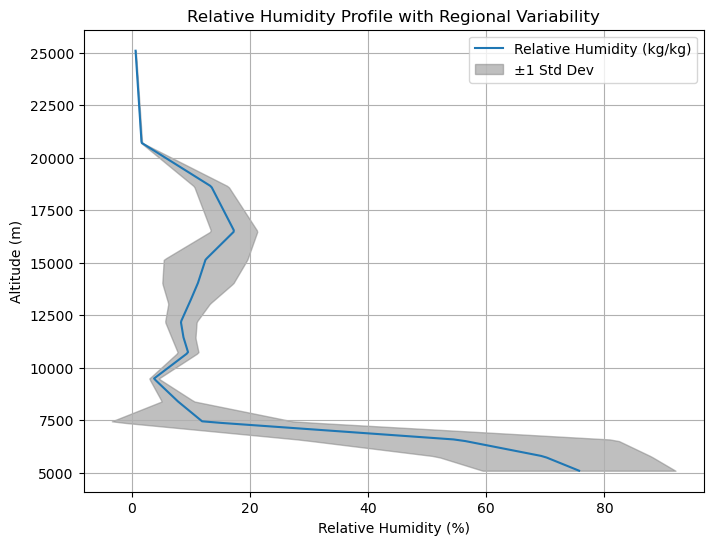

In [11]:
#Let's plot the specific humidity profile and its standard deviation to visualize the variability across the altitude profile
plt.figure(figsize=(8, 6))
plt.plot(rh_interp, altitude_profile, label='Relative Humidity (kg/kg)')
plt.fill_betweenx(altitude_profile, rh_interp - std_rh_interp, rh_interp + std_rh_interp, color='gray', alpha=0.5, label='±1 Std Dev')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Altitude (m)')
plt.title('Relative Humidity Profile with Regional Variability')
plt.legend()
plt.grid()
plt.show()

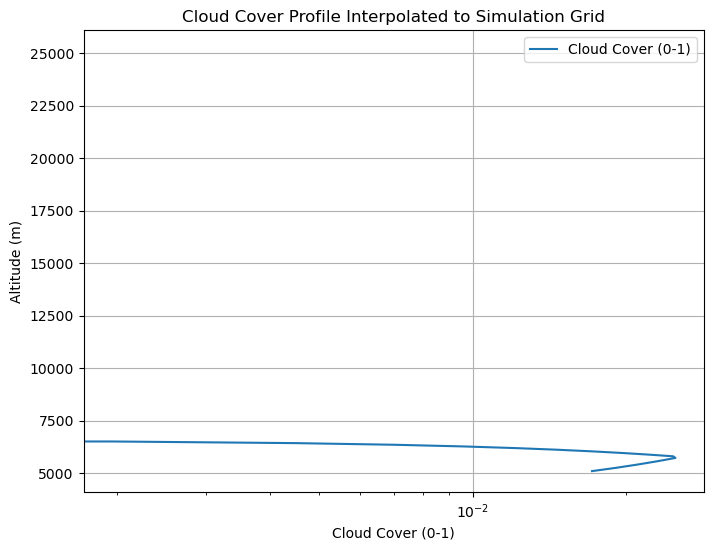

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(cc_interp, altitude_profile, label='Cloud Cover (0-1)')
plt.xlabel('Cloud Cover (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Cloud Cover Profile Interpolated to Simulation Grid')
plt.legend()
plt.xscale('log')
plt.grid()
plt.show()

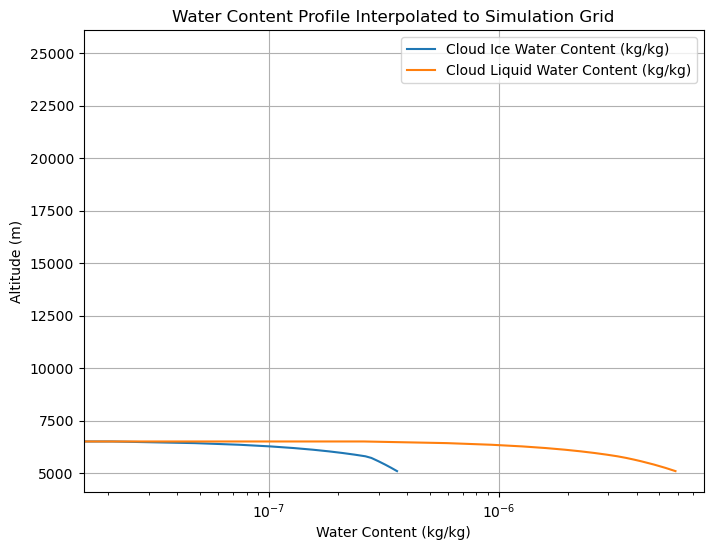

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(ciwc_interp, altitude_profile, label='Cloud Ice Water Content (kg/kg)')
plt.plot(clwc_interp, altitude_profile, label='Cloud Liquid Water Content (kg/kg)')
plt.xlabel('Water Content (kg/kg)')
plt.ylabel('Altitude (m)')
plt.title('Water Content Profile Interpolated to Simulation Grid')
plt.legend()
plt.grid()
plt.xscale('log')
plt.show()

In [5]:
k_array = np.arange(nside_grid[0]) * jnp.min(atmo_box.grid_wsp.dk)

k0_q  = 2*np.pi / q_injection_scale_in_m   # Water-vapour injection wavenumber (rad/m)
k0_ta = 2*np.pi / ta_injection_scale_in_m  # Temperature injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)
pofk_ta = ( k0_ta**2. + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)

# Pack into dictionaries expected by add_temperature / add_watervapor.
pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}

rescale = {'h': altitude_profile, 'f': std_q_interp} #we scale it with the regional variability

NameError: name 'std_q_interp' is not defined

In [57]:
seed = 123456789


# 1. Define your fluctuation scaling (zscale) as you suggested
custom_zscale = {'h': altitude_profile, 'f': std_q_interp}

# 2. Define your mean profile 
# (Assuming raw_specific_humidity is the un-calibrated ERA5 profile we got earlier)
custom_mean = {'h': altitude_profile, 'f': raw_specific_humidity}

# 3. Add the component using the internal _add_component method
atmo_box._add_component(
    field_name='q',                  # The name of your custom component
    field_unit='kg/kg',              # The physical unit
    pspec=pspec_q,                # Your power spectrum dict (e.g., {'k': k_array, 'pofk': pofk})
    zscale=custom_zscale,            # Scales the RMS amplitude of the fluctuations
    mean=custom_mean,                # Adds the background mean profile
    seed=seed                  # A unique random seed for this component
)

atmo_box.generate_realization(time_step=0)

# Extract your final 3D JAX arrays
q_variations_cube = atmo_box.components['q'].field

In [95]:
seed = 123456789


# 1. Define your fluctuation scaling (zscale) as you suggested
custom_zscale_rh = {'h': altitude_profile, 'f': std_rh_interp}

# 2. Define your mean profile 
# (Assuming raw_specific_humidity is the un-calibrated ERA5 profile we got earlier)
custom_mean_rh = {'h': altitude_profile, 'f': rh_interp}

# 3. Add the component using the internal _add_component method
atmo_box._add_component(
    field_name='rh',                  # The name of your custom component
    field_unit='%',              # The physical unit
    pspec=pspec_q,                # Your power spectrum dict (e.g., {'k': k_array, 'pofk': pofk})
    zscale=custom_zscale_rh,            # Scales the RMS amplitude of the fluctuations
    mean=custom_mean_rh,                # Adds the background mean profile
    seed=seed                  # A unique random seed for this component
)

atmo_box.generate_realization(time_step=0)

# Extract your final 3D JAX arrays
rh_variations_cube = atmo_box.components['rh'].field

In [58]:
from atmo3 import atm_utils as au
pressure_profile = atmo_box.super_grid.pressure

# 2. Reshape the 1D profiles to (1, 1, Nz) so they can broadcast across the 3D cube
# This effectively creates a 3D grid where T and P are constant horizontally
T_3d = temperature_profile.reshape(1, 1, -1)
P_3d = pressure_profile.reshape(1, 1, -1)

# 3. Calculate the Virtual Temperature (in Kelvin)
T_v_3d = au.virtual_temperature(T=T_3d, q=q_variations_cube)

# 4. Calculate Water Vapor Density (rho_wv) in kg/m^3
rho_wv_3d = au.water_vapor_density(q=q_variations_cube, P=P_3d, T_v=T_v_3d)

# 5. Calculate Relative Humidity
# Note: This function returns RH as a fraction (0.0 to 1.0)
rh_fraction_cube = au.water_vapor_density_to_rel_humidity(rho_wv=rho_wv_3d, T=T_3d)

# Convert to percentage (0% to 100%) if needed for your cloud cover checks
rh_percentage_cube = rh_fraction_cube * 100.0

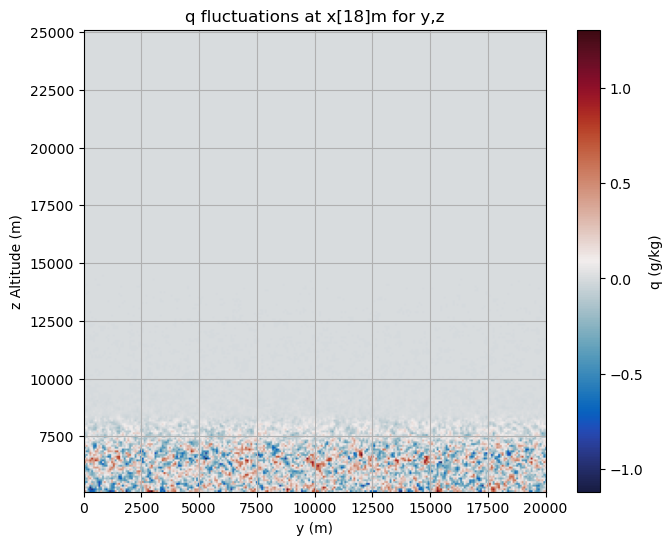

In [78]:
plt.figure(figsize=(8, 6))
plt.imshow(q_variations_cube[18,:,:].T*1e3,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='q (g/kg)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('q fluctuations at x[18]m for y,z')
plt.grid()
plt.show()

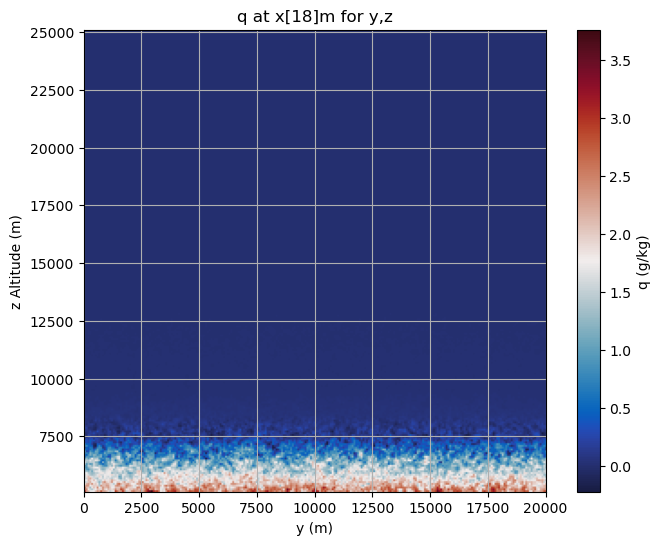

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(q_variations_cube[18,:,:].T*1e3+ raw_specific_humidity.reshape(1,1,-1)[18,:, :].T*1e3,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='q (g/kg)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('q (mean+fluctuations) at x[18]m for y,z')
plt.grid()
plt.show()

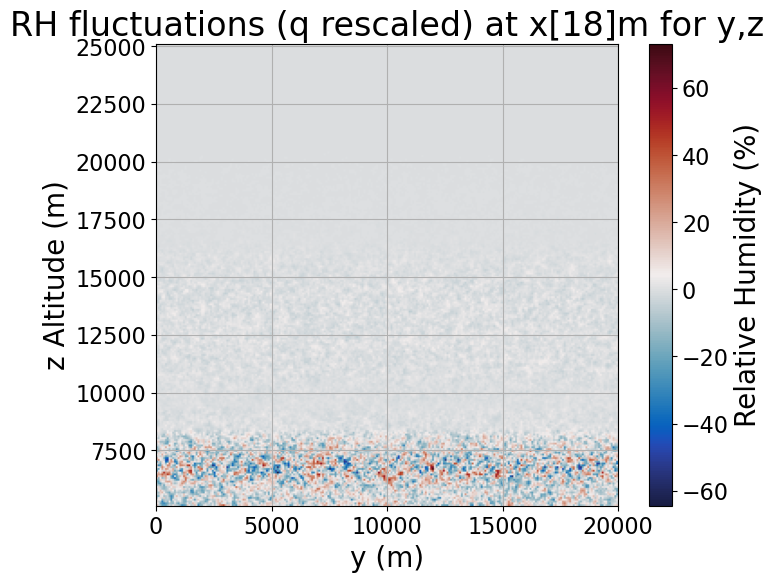

In [113]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_percentage_cube[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (q rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

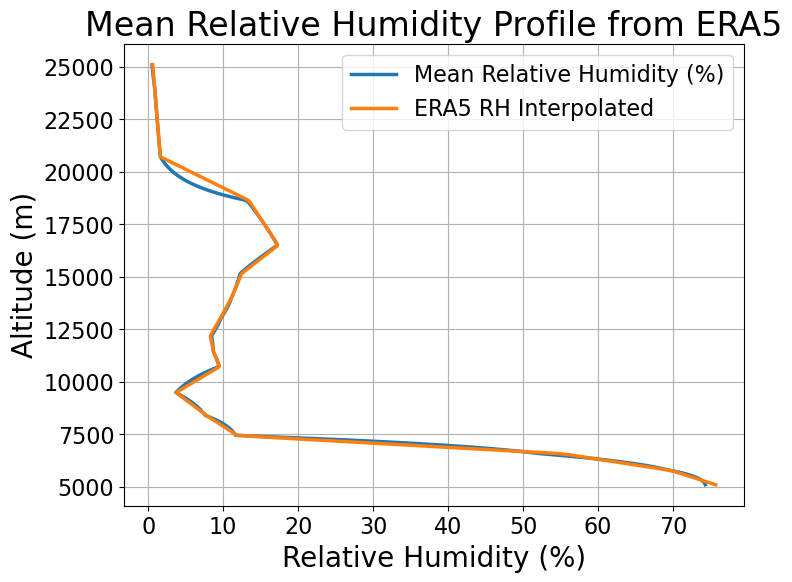

In [ ]:
virtual_temp1D = au.virtual_temperature(T=temperature_profile, q=raw_specific_humidity)
water_rho1D = au.water_vapor_density(q=raw_specific_humidity, P=pressure_profile, T_v=virtual_temp1D)
rh_mean1D = au.water_vapor_density_to_rel_humidity(rho_wv=water_rho1D, T=temperature_profile) * 100.0

plt.figure(figsize=(8, 6))
plt.plot(rh_mean1D, altitude_profile, label='Mean Relative Humidity (%)', linewidth=2.5)
plt.plot(rh_interp, altitude_profile, label='ERA5 RH Interpolated', linewidth=2.5)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Altitude (m)')
plt.title('Mean Relative Humidity Profile from ERA5')
plt.legend()
plt.grid()
plt.show()


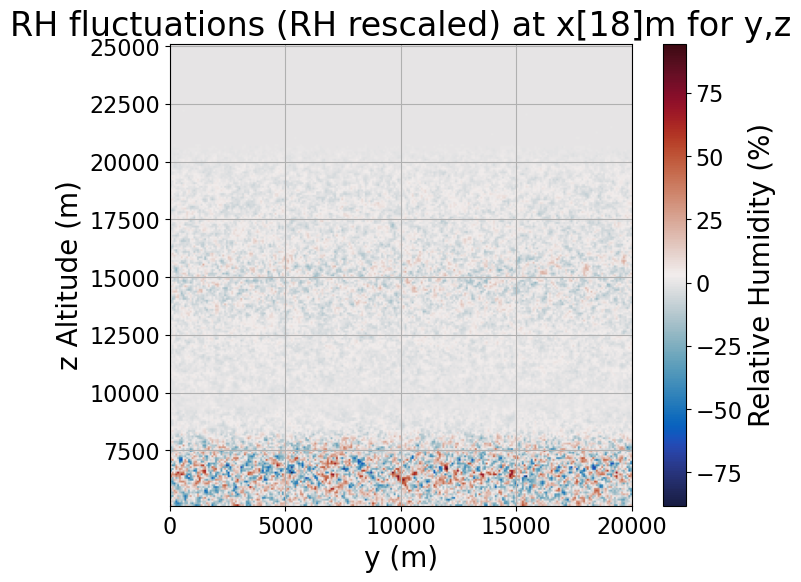

In [98]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_variations_cube[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (RH rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

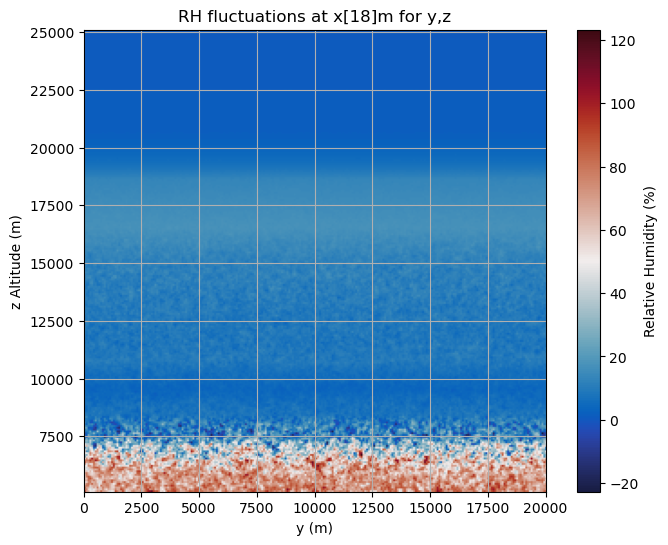

In [80]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_percentage_cube[18,:,:].T + rh_mean1D.reshape(1,1,-1)[18, :, :].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations at x[18]m for y,z')
plt.grid()
plt.show()

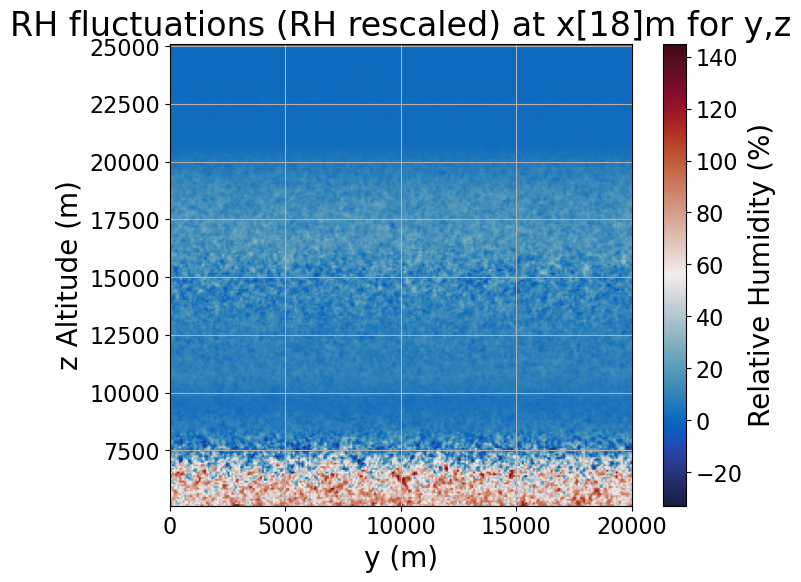

In [97]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_variations_cube[18,:,:].T + rh_interp.reshape(1,1,-1)[18, :, :].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (RH rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

In [83]:
import jax.numpy as jnp

# ==========================================
# Generate JAX Cloud Cube (Threshold RH > 1)
# ==========================================
rh_total_3d_grid = rh_percentage_cube/100 + rh_mean1D.reshape(1,1,-1)/100 # not in %  

# 1. (rh_tot > 1.0) creates a 3D boolean cube of True/False
# 2. .astype(jnp.int32) instantly converts True to 1 and False to 0
cloud_cube = (rh_total_3d_grid > 1.0).astype(jnp.int32)

cc_ratio_atmo3 = jnp.mean(cloud_cube, axis=(0,1))

In [99]:
rh_total_3d_grid_rh_rescaled = rh_variations_cube/100 + rh_interp.reshape(1,1,-1)/100 # no in %

cloud_cube_rh_rescaled = (rh_total_3d_grid_rh_rescaled > 1.0).astype(jnp.int32)

cc_ratio_atmo3_rh_rescaled = jnp.mean(cloud_cube_rh_rescaled, axis=(0,1))

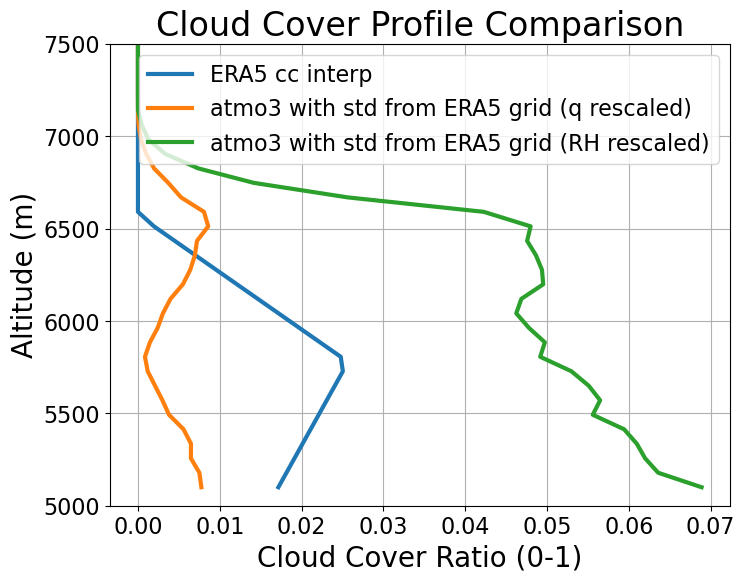

In [115]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp, altitude_profile, label='ERA5 cc interp')
plt.plot(cc_ratio_atmo3, altitude_profile, label='atmo3 with std from ERA5 grid (q rescaled)')
plt.plot(cc_ratio_atmo3_rh_rescaled, altitude_profile, label='atmo3 with std from ERA5 grid (RH rescaled)')
plt.xlabel('Cloud Cover Ratio (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Cloud Cover Profile Comparison')
plt.ylim(5000, 7500)
plt.legend()
plt.grid()
plt.show()

Let's apply the threshold on RH with apex calibration

In [7]:
seed = 123456789
atmo_box.add_watervapor(power_spec=pspec_q, seed=seed)

atmo_box.generate_realization(time_step=0, component_name='water vapor')

# Extract your final 3D JAX arrays
rho_water_variations_cube = atmo_box.components['water vapor'].field  # in kg/m^3

mean_dict = atmo_box.component_mean['water vapor']

# The dictionary contains 'h' (height/altitude) and 'f' (the mean values)
rho_water_mean_1d = mean_dict['f'] #in kg/m^3

In [8]:
rho_water_total_3d_grid = rho_water_variations_cube + rho_water_mean_1d.reshape(1,1,-1)

#let's calculate the RH
RH_mean_apex_rescaled = au.water_vapor_density_to_rel_humidity(rho_wv=rho_water_mean_1d, T=temperature_profile) * 100.0 

rh_apex_calibration_fluctuations = au.water_vapor_density_to_rel_humidity(rho_wv=rho_water_variations_cube, T=temperature_profile.reshape(1,1,-1)) * 100.0
rh_apex_calibration_total = au.water_vapor_density_to_rel_humidity(rho_wv=rho_water_total_3d_grid, T=temperature_profile.reshape(1,1,-1)) * 100.0

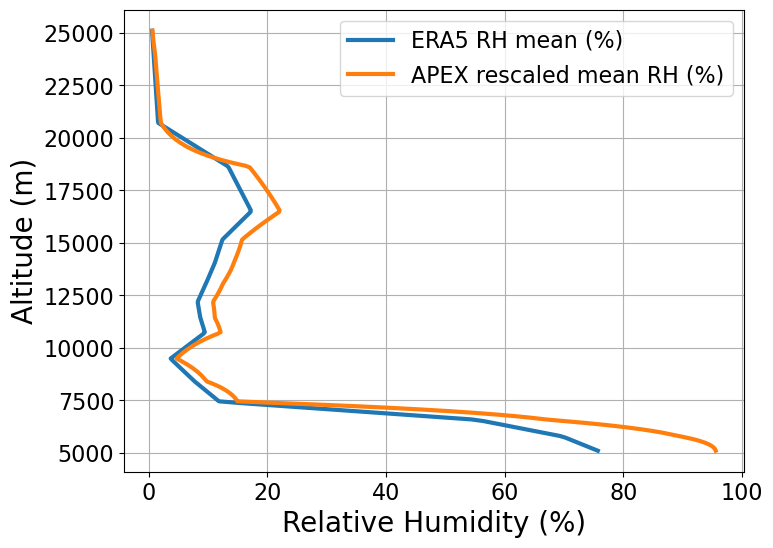

RH ERA5 mean at ground level (site altitude): 75.71053431097792
RH APEX rescaled mean at ground level (site altitude): 95.57929042876397


In [17]:
plt.figure(figsize=(8,6))
plt.plot(rh_interp, altitude_profile, label='ERA5 RH mean (%)')
plt.plot(au.water_vapor_density_to_rel_humidity(rho_wv= rho_water_mean_1d, T=temperature_profile) * 100.0, altitude_profile, label='APEX rescaled mean RH (%)')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Altitude (m)')
#plt.title('Mean Relative Humidity Profile from ERA5 vs Apex Calibration')
plt.legend()
plt.grid()
plt.show()

print("RH ERA5 mean at ground level (site altitude):", rh_interp[0])
print("RH APEX rescaled mean at ground level (site altitude):", RH_mean_apex_rescaled[0])

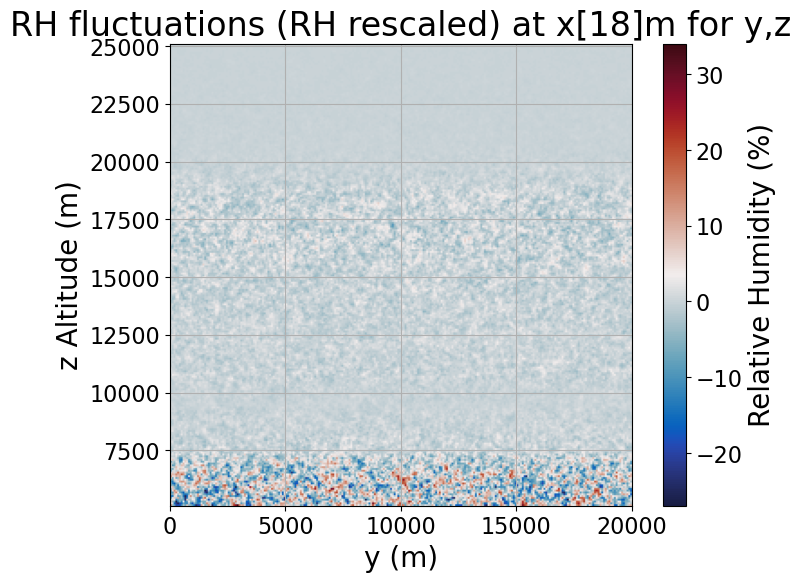

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_apex_calibration_fluctuations[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (Apex rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

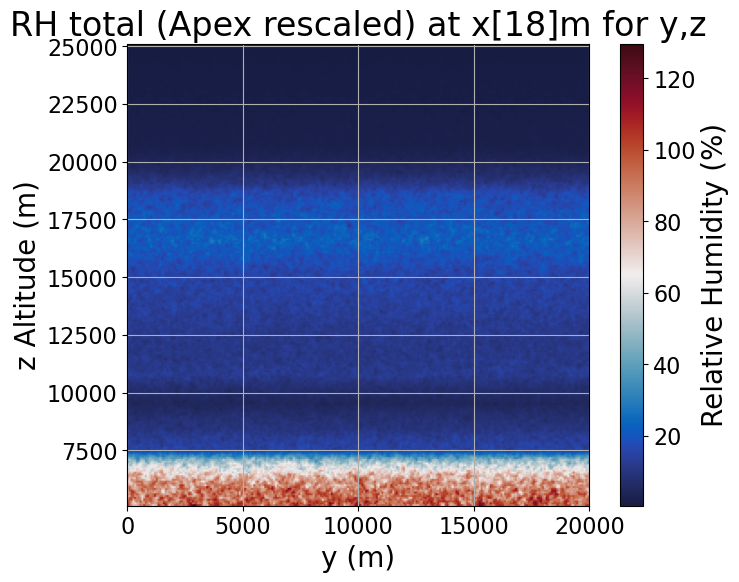

In [106]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_apex_calibration_total[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH total (Apex rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

In [108]:


cloud_cube_rh_apex_rescaled = (rh_apex_calibration_total/100.0 > 1.0).astype(jnp.int32)

cc_ratio_atmo3_rh_apex_rescaled = jnp.mean(cloud_cube_rh_apex_rescaled, axis=(0,1))

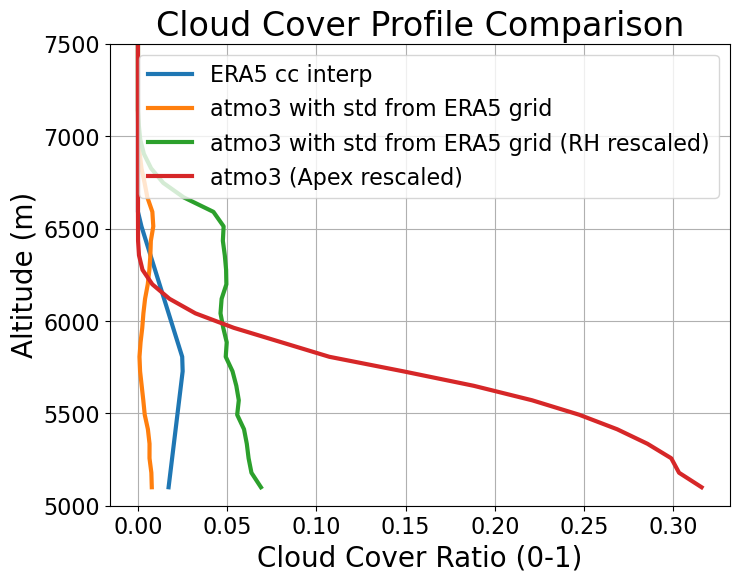

In [139]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp, altitude_profile, label='ERA5 cc interp')
plt.plot(cc_ratio_atmo3, altitude_profile, label='atmo3 with std from ERA5 grid')
plt.plot(cc_ratio_atmo3_rh_rescaled, altitude_profile, label='atmo3 with std from ERA5 grid (RH rescaled)')
plt.plot(cc_ratio_atmo3_rh_apex_rescaled, altitude_profile, label='atmo3 (Apex rescaled)')
plt.xlabel('Cloud Cover Ratio (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Cloud Cover Profile Comparison')
plt.ylim(5000, 7500)
plt.legend()
plt.grid()
plt.show()

Let's just try to obtain the same cloud cover ratio for the fluctuations

In [118]:
import numpy as np
from scipy.special import erfcinv

def compute_turbulence_profile(rh_mean, cc_era5, rh_thresh=1.0):
    """
    Calculates the turbulence scaling constant profile C(z)
    to match the ERA5 Cloud Cover fraction.
    
    Arguments:
    - rh_mean: 1D array of mean relative humidity profile (0.0 to 1.0+).
    - cc_era5: 1D array of ERA5 cloud cover profile (0.0 to 1.0).
    - rh_thresh: The threshold for cloud formation (default 1.0 for 100%).
    
    Returns:
    - c_z: 1D array of the turbulence scaling constant profile.
    """
    # 1. Mathematical safety: avoid strict 0 and 1 for the error function
    # erfcinv(0) = inf and erfcinv(2) = -inf
    cc_safe = np.clip(cc_era5, 1e-4, 0.9999)
    
    # 2. The denominator of the analytical equation
    denom = rh_mean * np.sqrt(2) * erfcinv(2.0 * cc_safe)
    
    # Safety to avoid division by zero (if rh_mean is exactly 0)
    denom = np.where(denom == 0, 1e-6, denom)
    
    # 3. Calculate the constant C(z)
    c_z = (rh_thresh - rh_mean) / denom
    
    # 4. Physical corrections
    # If ERA5 states there are STRICTLY no clouds (CC=0), kill the turbulence
    c_z = np.where(cc_era5 == 0, 0.0, c_z)
    
    # If rh_mean already exceeds the threshold (air is over-saturated), the mathematical
    # formula yields a negative C(z). The variance must always be positive.
    # This physically represents the variance needed to reach the clear-sky threshold.
    c_z = np.abs(c_z)
    
    return c_z

C_z_profile = compute_turbulence_profile(rh_interp/100.0, cc_interp)

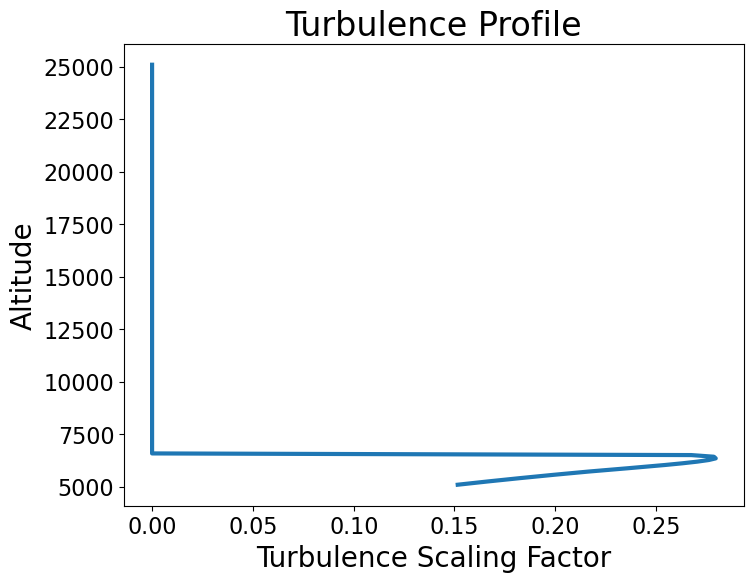

In [119]:
plt.figure(figsize=(8,6))
plt.plot(C_z_profile, altitude_profile)
plt.xlabel('Turbulence Scaling Factor')
plt.ylabel('Altitude')
plt.title('Turbulence Profile')
plt.show()

In [131]:
seed = 123456789


# 1. Define your fluctuation scaling (zscale) as you suggested
custom_zscale_factor = {'h': altitude_profile, 'f': cc_interp*raw_specific_humidity} # we apply a rescale to obtain the same cc as ERA5

# 2. Define your mean profile 
# (Assuming raw_specific_humidity is the un-calibrated ERA5 profile we got earlier)
custom_mean = {'h': altitude_profile, 'f': raw_specific_humidity}

# 3. Add the component using the internal _add_component method
atmo_box._add_component(
    field_name='q',                  # The name of your custom component
    field_unit='kg/kg',              # The physical unit
    pspec=pspec_q,                # Your power spectrum dict (e.g., {'k': k_array, 'pofk': pofk})
    zscale=custom_zscale_factor,            # Scales the RMS amplitude of the fluctuations
    mean=custom_mean,                # Adds the background mean profile
    seed=seed                  # A unique random seed for this component
)

atmo_box.generate_realization(time_step=0)

# Extract your final 3D JAX arrays
q_variations_cube_factor_rescaled = atmo_box.components['q'].field

In [132]:
from atmo3 import atm_utils as au
pressure_profile = atmo_box.super_grid.pressure

# 2. Reshape the 1D profiles to (1, 1, Nz) so they can broadcast across the 3D cube
# This effectively creates a 3D grid where T and P are constant horizontally
T_3d = temperature_profile.reshape(1, 1, -1)
P_3d = pressure_profile.reshape(1, 1, -1)

# 3. Calculate the Virtual Temperature (in Kelvin)
T_v_3d = au.virtual_temperature(T=T_3d, q=q_variations_cube_factor_rescaled)

# 4. Calculate Water Vapor Density (rho_wv) in kg/m^3
rho_wv_3d = au.water_vapor_density(q=q_variations_cube_factor_rescaled, P=P_3d, T_v=T_v_3d)


rh_factor_rescaled_fluctuations = au.water_vapor_density_to_rel_humidity(rho_wv=rho_wv_3d, T=T_3d) * 100.0

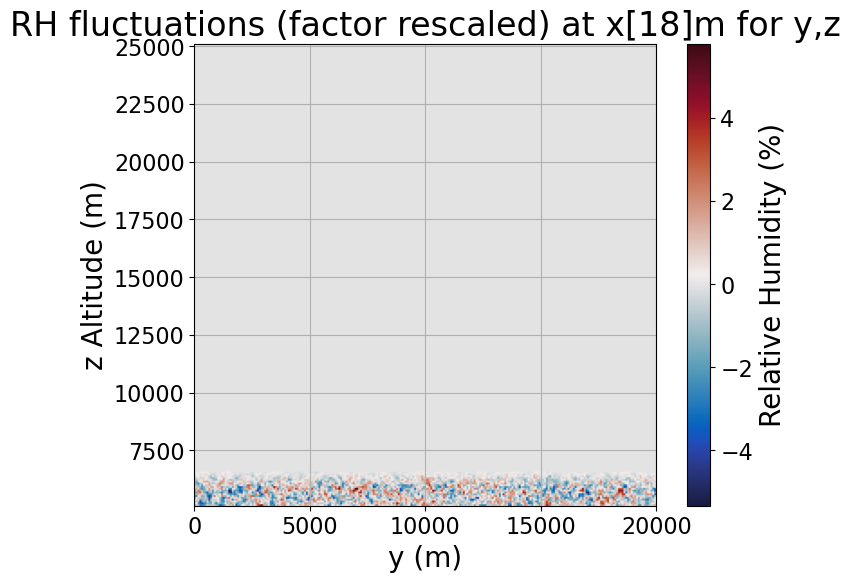

In [133]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_factor_rescaled_fluctuations[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (factor rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

In [134]:
rh_factor_rescaled_total = au.water_vapor_density_to_rel_humidity(rho_wv=rho_wv_3d + rho_water_mean_1d.reshape(1,1,-1), T=T_3d) * 100.0

cloud_cube_rh_factor_rescaled = (rh_factor_rescaled_total/100.0 > 1.0).astype(jnp.int32)

cc_ratio_atmo3_rh_factor_rescaled = jnp.mean(cloud_cube_rh_factor_rescaled, axis=(0,1))

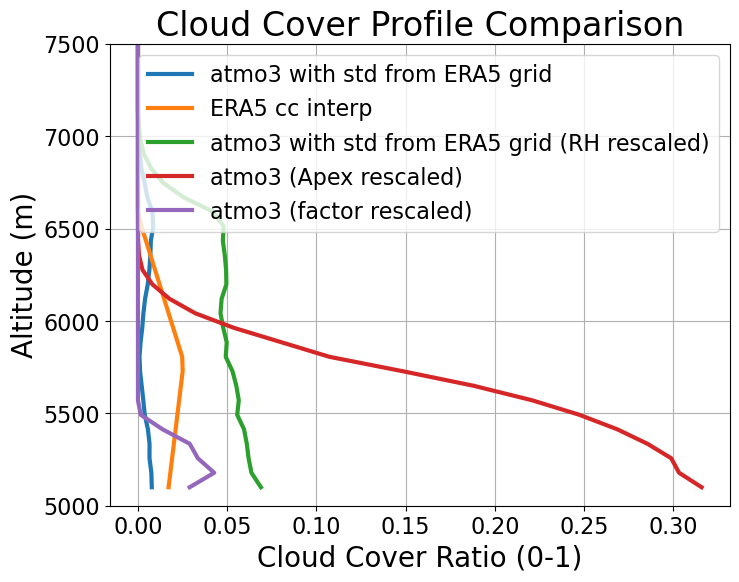

In [138]:
plt.figure(figsize=(8,6))
plt.plot(cc_ratio_atmo3, altitude_profile, label='atmo3 with std from ERA5 grid')
plt.plot(cc_interp, altitude_profile, label='ERA5 cc interp')
plt.plot(cc_ratio_atmo3_rh_rescaled, altitude_profile, label='atmo3 with std from ERA5 grid (RH rescaled)')
plt.plot(cc_ratio_atmo3_rh_apex_rescaled, altitude_profile, label='atmo3 (Apex rescaled)')
plt.plot(cc_ratio_atmo3_rh_factor_rescaled*100, altitude_profile, label='atmo3 (factor rescaled)')
plt.xlabel('Cloud Cover Ratio (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Cloud Cover Profile Comparison')
plt.ylim(5000, 7500)
plt.legend()
plt.grid()
plt.show()

Let's look at a new profile

In [140]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 256]
box_length = [20000., 20000., 20000.]

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 9, 22, 18, 0, tzinfo=timezone.utc)

# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for September 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ccfile     = f'{atmo3_data}era5/2023/cc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ciwcfile   = f'{atmo3_data}era5/2023/ciwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
clwcfile   = f'{atmo3_data}era5/2023/clwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
rhfile     = f'{atmo3_data}era5/2023/r.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

atmo_box22sep = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)


0.9088524590163933 0.10638136366638248


In [141]:
altitude_profile22 = atmo_box22sep.super_grid.z
cc_interp22 = atmo_box22sep.super_grid.era5_interp2site(ccfile)

ciwc_interp22 = atmo_box22sep.super_grid.era5_interp2site(ciwcfile)
clwc_interp22 = atmo_box22sep.super_grid.era5_interp2site(clwcfile)

rh_interp22 = atmo_box22sep.super_grid.era5_interp2site(rhfile)

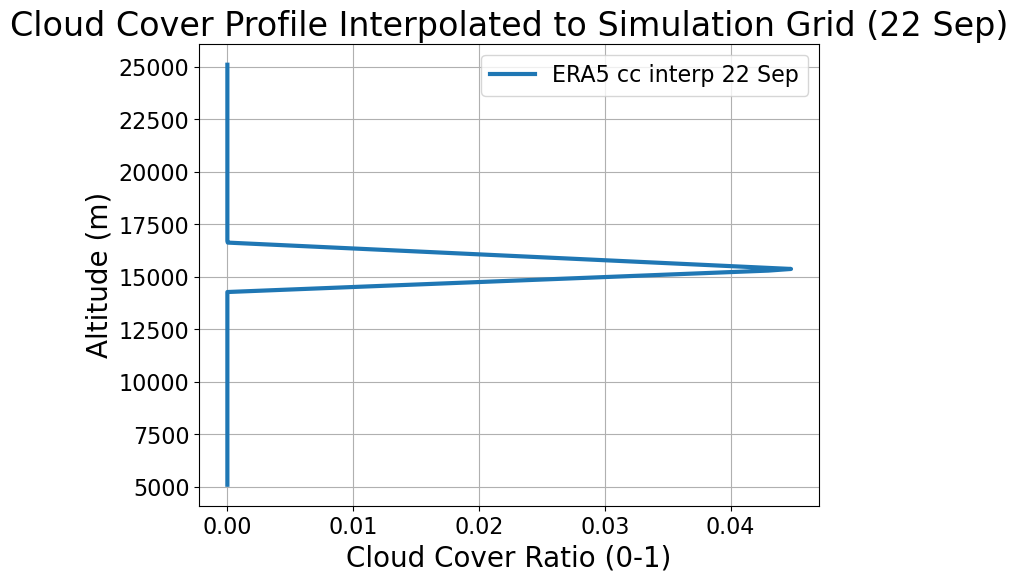

In [142]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp22, altitude_profile22, label='ERA5 cc interp 22 Sep')
plt.xlabel('Cloud Cover Ratio (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Cloud Cover Profile Interpolated to Simulation Grid (22 Sep)')
#plt.ylim(5000, 7500)
plt.legend()
plt.grid()
plt.show()

Little look at the APEX data for our date

In [16]:
import pandas as pd

time_utc = datetime(2023, 9, 3, 23, 0, tzinfo=timezone.utc)

# 1. Define your target time and the +/- 30 minute window
# We remove timezone info to perfectly match pandas datetime parsing
t0 = pd.Timestamp(time_utc).replace(tzinfo=None)
t_start = t0 - pd.Timedelta(minutes=30)
t_end   = t0 + pd.Timedelta(minutes=30)

# 2. Read the APEX data in chunks to save memory
chunks = []
for chunk in pd.read_csv(
    apexfile,
    header=None,
    names=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed'],
    parse_dates=['UT'],
    chunksize=1024
):
    # Filter rows that fall within our 1-hour window
    chunk_filtered = chunk[(chunk['UT'] >= t_start) & (chunk['UT'] <= t_end)]
    if not chunk_filtered.empty:
        chunks.append(chunk_filtered)
        
# Combine the filtered chunks into a single DataFrame
apexdata = pd.concat(chunks) if chunks else pd.DataFrame(
    columns=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed']
)

# 3. Convert APEX temperature from Celsius to Kelvin (like atmo3 does)
apexdata['Temperature'] += 273.15

# 4. Extract the exact statistics atmo3 uses for calibration
apex_pwv_mean = apexdata['PWV'].mean()
apex_pwv_std  = apexdata['PWV'].std()
apex_temperature_mean = apexdata['Temperature'].mean()
apex_temperature_std  = apexdata['Temperature'].std()
apex_humidity_mean = apexdata['Humidity'].mean()
apex_humidity_std  = apexdata['Humidity'].std()

# 5. Print the raw dataframe and the calculated stats
print(f"--- APEX Data Window ({t_start} to {t_end}) ---")
display(apexdata) # Use print(apexdata) if not in a Jupyter Notebook

print("\n--- Calibration Stats used by atmo3 ---")
print(f"APEX Mean PWV: {apex_pwv_mean:.3f} mm, Std: {apex_pwv_std:.3f} mm")
print(f"APEX Mean Temp: {apex_temperature_mean:.3f} K, Std: {apex_temperature_std:.3f} K")
print(f"APEX Mean Humidity: {apex_humidity_mean:.3f} %, Std: {apex_humidity_std:.3f} %")

--- APEX Data Window (2023-09-03 22:30:00 to 2023-09-03 23:30:00) ---


,UT,PWV,Temperature,Humidity,Wind_Dir,Wind_Speed
8729349,2023-09-03 22:30:00,NaN,263.95,61.3,280,15.0
8729350,2023-09-03 22:31:00,NaN,263.85,61.4,281,12.0
8729351,2023-09-03 22:32:00,NaN,263.95,61.8,280,14.9
8729352,2023-09-03 22:33:00,NaN,263.95,61.6,280,11.6
8729353,2023-09-03 22:34:00,NaN,263.95,61.7,280,11.4
...,...,...,...,...,...,...
8729405,2023-09-03 23:26:00,2.57,262.25,68.6,284,14.8
8729406,2023-09-03 23:27:00,2.57,262.15,68.6,285,14.0
8729407,2023-09-03 23:28:00,2.60,262.35,68.1,288,15.3
8729408,2023-09-03 23:29:00,2.56,262.55,67.9,288,12.5



--- Calibration Stats used by atmo3 ---
APEX Mean PWV: 2.526 mm, Std: 0.076 mm
APEX Mean Temp: 263.070 K, Std: 0.580 K
APEX Mean Humidity: 65.077 %, Std: 2.182 %
